# Introducción del proyecto

# Telecom X – Predicción de Cancelación de Clientes

## Objetivo

El objetivo de este proyecto es desarrollar modelos de Machine Learning capaces de predecir la cancelación de clientes (churn) en la empresa Telecom X.

A partir de los datos tratados en la Parte 1 del desafío, se aplicarán técnicas de análisis exploratorio, preparación de datos y modelado predictivo para identificar los factores que influyen en la cancelación y proponer estrategias de retención.

# **IMPORTAMOS LIBRERIAS**

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **1: CARGAMOS DATOS**

In [27]:
## Usamos el archivo del challenge parte 1 ##

df = pd.read_csv("datos_tratados.csv")

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuenta_Diaria,Cantidad_Servicios
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,4
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,3
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,2
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,5
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,3


In [28]:
## Verificamos la estructura ##

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7256 non-null   object 
 1   Churn               7032 non-null   object 
 2   gender              7256 non-null   object 
 3   SeniorCitizen       7256 non-null   int64  
 4   Partner             7256 non-null   object 
 5   Dependents          7256 non-null   object 
 6   tenure              7256 non-null   int64  
 7   PhoneService        7256 non-null   object 
 8   MultipleLines       7256 non-null   object 
 9   InternetService     7256 non-null   object 
 10  OnlineSecurity      7256 non-null   object 
 11  OnlineBackup        7256 non-null   object 
 12  DeviceProtection    7256 non-null   object 
 13  TechSupport         7256 non-null   object 
 14  StreamingTV         7256 non-null   object 
 15  StreamingMovies     7256 non-null   object 
 16  Contra

# **2: Preparación de datos**

In [29]:
## Eliminar columnas irrelevantes ##

df = df.drop("customerID", axis=1)

In [30]:
## Convertir variables categóricas ##

df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuenta_Diaria,Cantidad_Servicios,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.186667,4,False,False,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,1.996667,3,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,2,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.266667,5,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.796667,3,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


# **3: Análisis del balance de clases**

In [31]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [32]:
## Proporción ##

df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.734215
Yes,0.265785


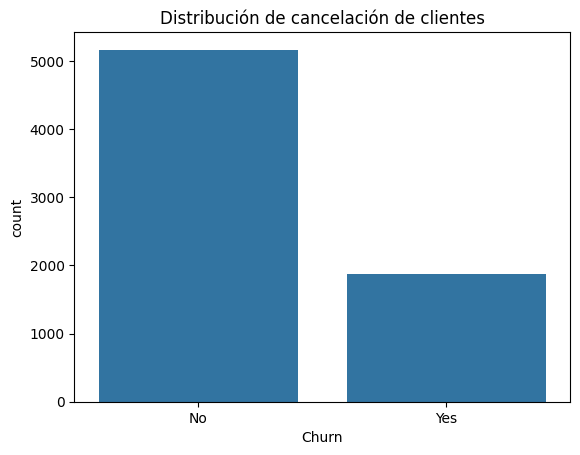

In [33]:
## Visualización ##

sns.countplot(x="Churn", data=df)

plt.title("Distribución de cancelación de clientes")
plt.show()

# **4: Matriz de correlación**

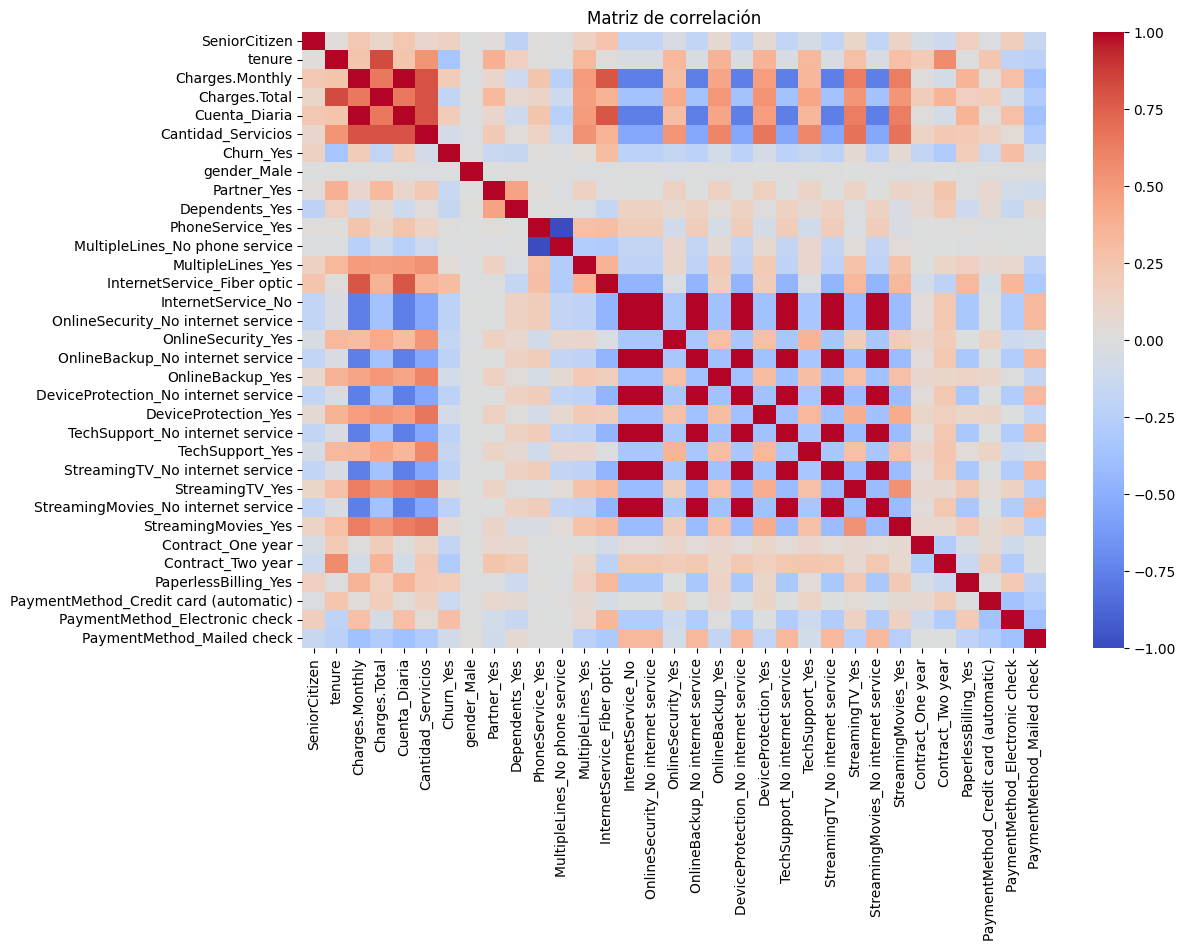

In [34]:
plt.figure(figsize=(12,8))

sns.heatmap(df_encoded.corr(), cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

In [35]:
## Ver correlación con churn ##

df_encoded.corr()["Churn_Yes"].sort_values(ascending=False)

,Churn_Yes
Churn_Yes,1.000000
InternetService_Fiber optic,0.300416
PaymentMethod_Electronic check,0.294181
Cuenta_Diaria,0.189393
Charges.Monthly,0.189393
PaperlessBilling_Yes,0.186309
SeniorCitizen,0.146400
StreamingTV_Yes,0.062456
StreamingMovies_Yes,0.060092
MultipleLines_Yes,0.039277


# **5: División de datos**

In [36]:
## Separar variables ##

X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

In [37]:
## Dividir datos ##

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# **6: Normalización**

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **7: Entrenamiento de modelos**

In [39]:
## Logistic Regression ##

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [40]:
## Decision Tree ##

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

# **8: Evaluación de modelos**

In [41]:
## Logistic Regression ##

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8075333027101516
              precision    recall  f1-score   support

       False       0.85      0.90      0.88      1630
        True       0.64      0.53      0.58       547

    accuracy                           0.81      2177
   macro avg       0.75      0.71      0.73      2177
weighted avg       0.80      0.81      0.80      2177



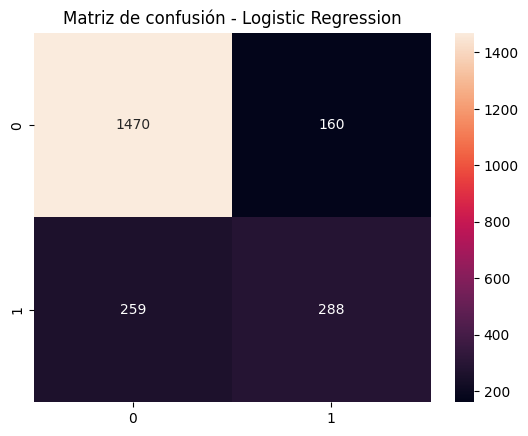

In [42]:
## Matriz de confusión ##

cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de confusión - Logistic Regression")

plt.show()

In [43]:
## Decision Tree ##

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.7294441892512632
              precision    recall  f1-score   support

       False       0.83      0.81      0.82      1630
        True       0.46      0.49      0.48       547

    accuracy                           0.73      2177
   macro avg       0.64      0.65      0.65      2177
weighted avg       0.73      0.73      0.73      2177



In [44]:
## Random Forest para analizar importancia ##

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

importances = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
})

importances = importances.sort_values(by="Importancia", ascending=False)

importances.head(10)

,Variable,Importancia
3,Charges.Total,0.166447
1,tenure,0.141599
4,Cuenta_Diaria,0.122573
2,Charges.Monthly,0.121666
12,InternetService_Fiber optic,0.036025
5,Cantidad_Servicios,0.034987
30,PaymentMethod_Electronic check,0.033622
27,Contract_Two year,0.026981
21,TechSupport_Yes,0.025542
6,gender_Male,0.024910


# **9: Importancia de variables**

In [45]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

importances = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
})

importances = importances.sort_values(by="Importancia", ascending=False)

importances.head(10)

,Variable,Importancia
3,Charges.Total,0.166447
1,tenure,0.141599
4,Cuenta_Diaria,0.122573
2,Charges.Monthly,0.121666
12,InternetService_Fiber optic,0.036025
5,Cantidad_Servicios,0.034987
30,PaymentMethod_Electronic check,0.033622
27,Contract_Two year,0.026981
21,TechSupport_Yes,0.025542
6,gender_Male,0.024910


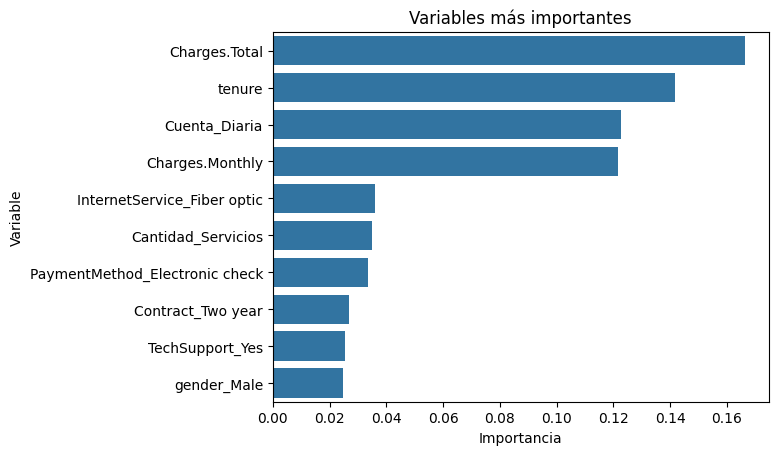

In [46]:
## Gráfico ##

sns.barplot(
    x="Importancia",
    y="Variable",
    data=importances.head(10)
)

plt.title("Variables más importantes")

plt.show()

# **10: Conclusión estratégica**

## Informe Final – Análisis de Cancelación de Clientes

En este proyecto se desarrollaron modelos de Machine Learning con el objetivo de predecir qué clientes tienen mayor probabilidad de cancelar su servicio en Telecom X. Para lograrlo, primero se prepararon los datos, se analizaron las variables más importantes y luego se entrenaron distintos modelos para evaluar su rendimiento.

Durante el análisis se observó que algunas variables tienen una influencia clara en la cancelación de los clientes. Entre los factores más importantes destacan el tipo de contrato, el tiempo que el cliente lleva con la empresa (tenure) y los cargos mensuales que paga el cliente.

Por ejemplo, los clientes que tienen contratos mensuales muestran una mayor tendencia a cancelar el servicio en comparación con aquellos que tienen contratos de uno o dos años. Esto puede deberse a que los contratos largos generan mayor compromiso con la empresa.

También se observó que los clientes que llevan menos tiempo en la empresa tienen más probabilidad de cancelar el servicio. Esto sugiere que los primeros meses del cliente son una etapa crítica donde la empresa debería enfocarse más en su satisfacción.

Otro factor importante son los cargos mensuales. Algunos clientes que pagan cargos más altos presentan mayor probabilidad de cancelar el servicio, lo que podría indicar que perciben que el costo es elevado en relación al beneficio que reciben.

En cuanto a los modelos utilizados, se aplicaron diferentes algoritmos de clasificación para predecir la cancelación de clientes. Al evaluar métricas como accuracy, precision, recall y F1-score, se pudo comparar el rendimiento de cada modelo y entender qué tan bien lograban identificar a los clientes con riesgo de churn.

Gracias a estos resultados, se pueden proponer algunas estrategias que Telecom X podría aplicar para reducir la cancelación de clientes. Una de ellas sería ofrecer incentivos para que los clientes cambien de contratos mensuales a contratos de mayor duración. Otra estrategia sería crear programas de fidelización dirigidos especialmente a los clientes nuevos, ya que son los que presentan mayor riesgo de cancelación.

También podría ser útil ofrecer promociones o beneficios a clientes con cargos mensuales más altos para mejorar su percepción del servicio.

En conclusión, este análisis permitió identificar patrones importantes en el comportamiento de los clientes y demostrar cómo el uso de modelos predictivos puede ayudar a las empresas a anticiparse a la cancelación. De esta manera, Telecom X podría tomar decisiones más informadas para mejorar la retención de clientes y fortalecer su relación con ellos.